# EDA Example

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The data file is a csv textfile, with value seperated by a semicolon (;).

In [4]:
bank_data = pd.read_csv("./bank-full.csv", sep=";")

In [5]:
bank_data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
bank_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
bank_data.shape

(45211, 17)

## Cross Tabulation
Use cross tabulation to describe a relation between 2 variables (columns) in the dataset.

For instance, we can use cross tabulation to see the relation between previous outcome (poutcome) with the current outcome/result (y).

In [8]:
crosstab = pd.crosstab(bank_data['poutcome'],bank_data['y'])

In [9]:
crosstab # let's see what it looks like

y,no,yes
poutcome,,
failure,4283,618
other,1533,307
success,533,978
unknown,33573,3386


## Using Overlay to Display Cross Tabulation

We can stack values in a graph to see the comparison clearly.

<Axes: xlabel='poutcome'>

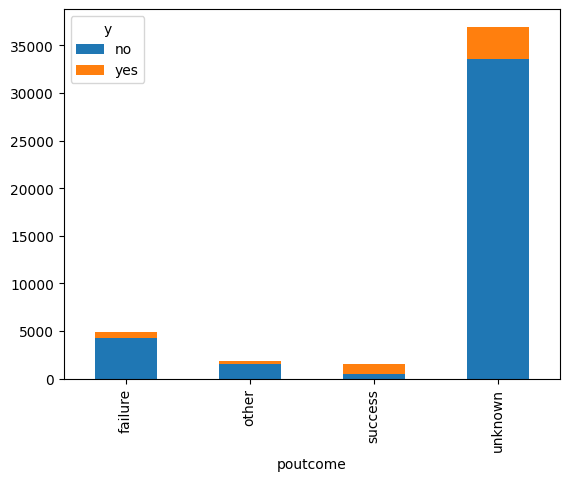

In [10]:
crosstab.plot(kind='bar', stacked=True)

## Normalizing Cross Tabulation
If we use the real-value scale, some bars can be to small to see. Another way to view the relation is looking at the proportions of each category.

In [11]:
crosstab_norm = crosstab.div(crosstab.sum(1), axis=0)

/var/folders/66/6vw881g500n1tz4mtjf1x44m0000gn/T/ipykernel_92089/3125942405.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  crosstab_norm = crosstab.div(crosstab.sum(1), axis=0)


In [12]:
crosstab_norm

y,no,yes
poutcome,,
failure,0.873903,0.126097
other,0.833152,0.166848
success,0.352747,0.647253
unknown,0.908385,0.091615


<Axes: xlabel='poutcome'>

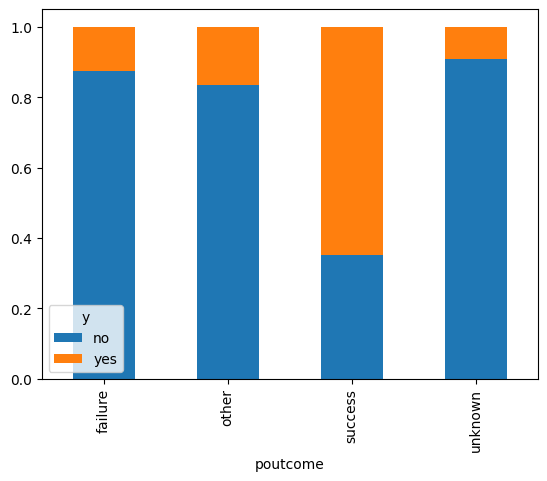

In [13]:
crosstab_norm.plot(kind='bar', stacked=True)

## Histogram Overlay
Since continous values are not appropriate for cross tabulation, to create histogram overlay a bit more work needs to be done.

In [14]:
# get age and response data
bank_age_yes = bank_data[bank_data['y']=='yes']['age']
bank_age_no = bank_data[bank_data['y']=='no']['age']

In [15]:
type(bank_age_yes)

pandas.Series

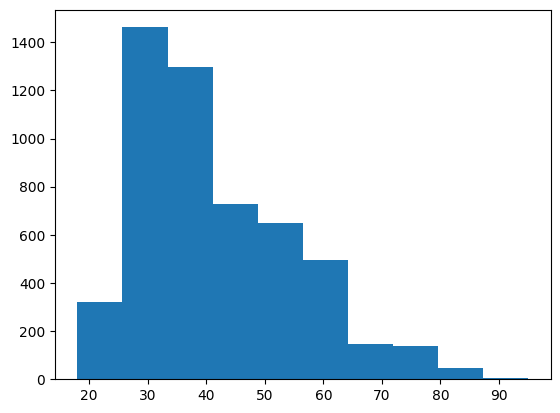

In [16]:
# plot 'yes' response only
plt.hist(bank_age_yes, bins=10)
plt.show()

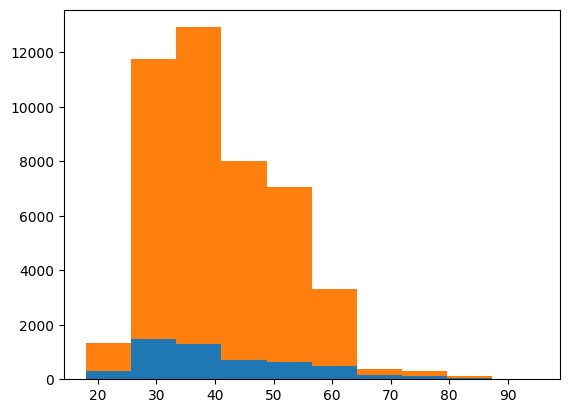

In [17]:
# plot both stacked
plt.hist([bank_age_yes,bank_age_no], bins=10, stacked=True)
plt.show()

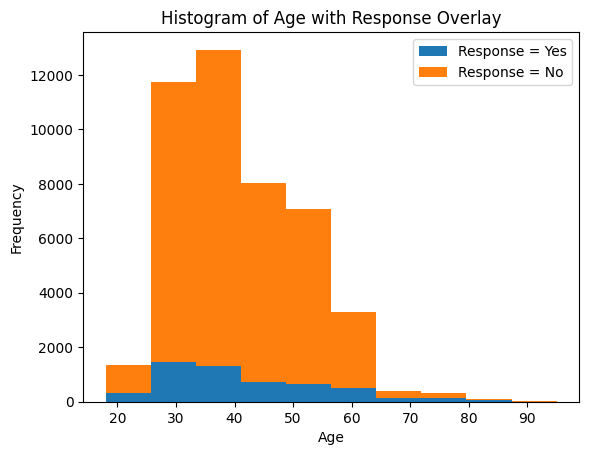

In [18]:
# Making the graph more readable
plt.hist([bank_age_yes,bank_age_no], bins=10, stacked=True)
plt.legend(['Response = Yes', 'Response = No'])
plt.title('Histogram of Age with Response Overlay')
plt.xlabel('Age') 
plt.ylabel('Frequency')
plt.show()

## Normalizing Histogram

Read about plt.hist() return values <a href="https://matplotlib.org/3.5.1/api/_as_gen/matplotlib.pyplot.hist.html">here</a>

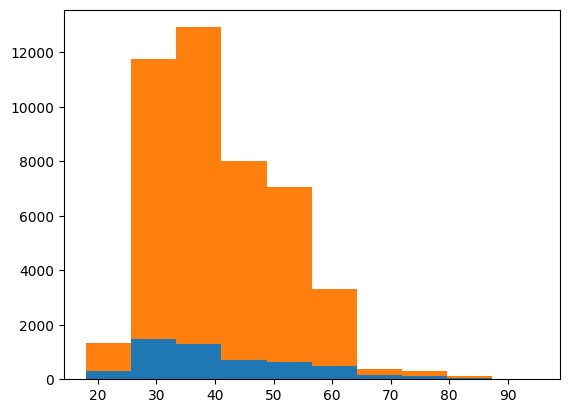

In [19]:
(n, bins, patches) = plt.hist([bank_age_yes,bank_age_no], bins=10, stacked=True)

In [20]:
n #height of the bars

array([[3.2000e+02, 1.4620e+03, 1.2950e+03, 7.2600e+02, 6.4800e+02,
        4.9700e+02, 1.4800e+02, 1.3800e+02, 4.8000e+01, 7.0000e+00],
       [1.3360e+03, 1.1747e+04, 1.2925e+04, 8.0150e+03, 7.0660e+03,
        3.3120e+03, 3.7700e+02, 3.0300e+02, 1.1600e+02, 1.4000e+01]])

In [21]:
bins #bin borders

array([18. , 25.7, 33.4, 41.1, 48.8, 56.5, 64.2, 71.9, 79.6, 87.3, 95. ])

In [22]:
#making list of pairs
n_table = np.column_stack((n[0], n[1]))
n_table

array([[3.2000e+02, 1.3360e+03],
       [1.4620e+03, 1.1747e+04],
       [1.2950e+03, 1.2925e+04],
       [7.2600e+02, 8.0150e+03],
       [6.4800e+02, 7.0660e+03],
       [4.9700e+02, 3.3120e+03],
       [1.4800e+02, 3.7700e+02],
       [1.3800e+02, 3.0300e+02],
       [4.8000e+01, 1.1600e+02],
       [7.0000e+00, 1.4000e+01]])

In [23]:
#normalize the bar heights
n_norm  = n_table / n_table.sum(axis=1)[:, None]
n_norm

array([[0.19323671, 0.80676329],
       [0.11068211, 0.88931789],
       [0.09106892, 0.90893108],
       [0.08305686, 0.91694314],
       [0.08400311, 0.91599689],
       [0.13048044, 0.86951956],
       [0.28190476, 0.71809524],
       [0.31292517, 0.68707483],
       [0.29268293, 0.70731707],
       [0.33333333, 0.66666667]])

In [24]:
#list of bins
ourbins = np.column_stack((bins[0:10], bins[1:11]))
ourbins

array([[18. , 25.7],
       [25.7, 33.4],
       [33.4, 41.1],
       [41.1, 48.8],
       [48.8, 56.5],
       [56.5, 64.2],
       [64.2, 71.9],
       [71.9, 79.6],
       [79.6, 87.3],
       [87.3, 95. ]])

<BarContainer object of 10 artists>

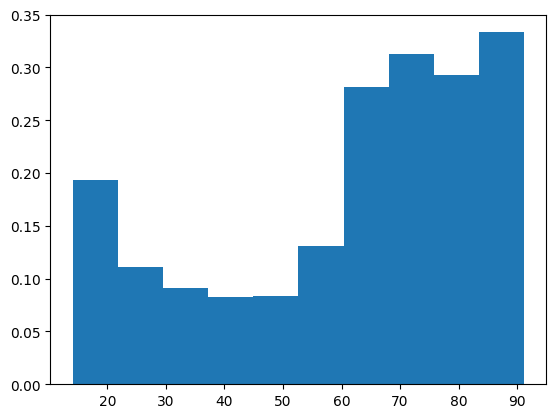

In [25]:
#plot bottom bars
plt.bar(x = ourbins[:,0], height = n_norm[:,0], width = ourbins[:, 1] - ourbins[:, 0])

<BarContainer object of 10 artists>

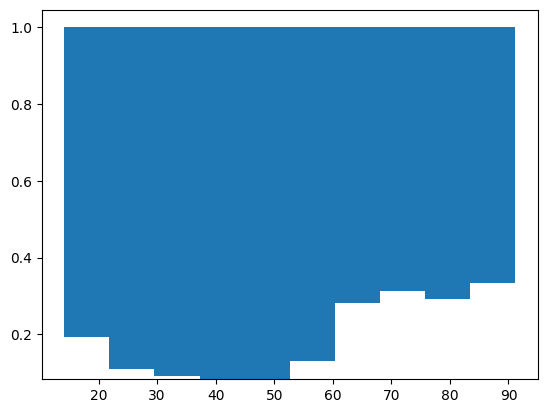

In [26]:
#plot upper bars
plt.bar(x = ourbins[:,0], height = n_norm[:,1], width = ourbins[:, 1] - ourbins[:, 0], bottom = n_norm[:,0])

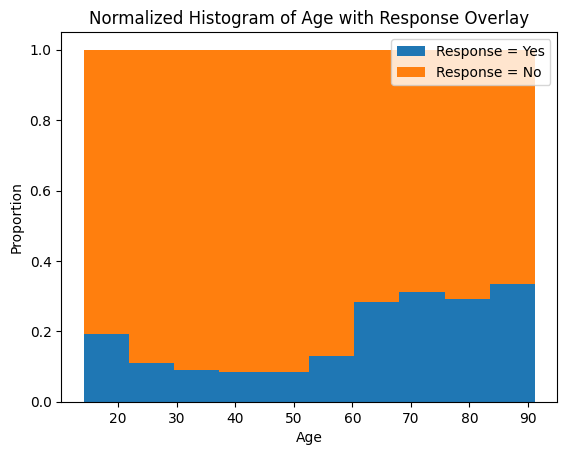

In [27]:
#plot both
plt.bar(x = ourbins[:,0], height = n_norm[:,0], width = ourbins[:, 1] - ourbins[:, 0])
plt.bar(x = ourbins[:,0], height = n_norm[:,1], width = ourbins[:, 1] - ourbins[:, 0], bottom = n_norm[:,0])
plt.legend(['Response = Yes', 'Response = No'])
plt.title('Normalized Histogram of Age with Response Overlay')
plt.xlabel('Age'); plt.ylabel('Proportion'); plt.show()

## Custom Binning
We can also define the size of each bin.

In [28]:
bank_data['age_binned'] = pd.cut(x = bank_data['age'], bins = [0, 27, 60.01, 100], labels=["Under 27", "27 to 60", "Over 60"], right = False)

In [29]:
bank_data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,age_binned
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,27 to 60
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,27 to 60
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,27 to 60
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,27 to 60
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,27 to 60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,27 to 60
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,Over 60
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,Over 60
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,27 to 60


<Axes: xlabel='age_binned'>

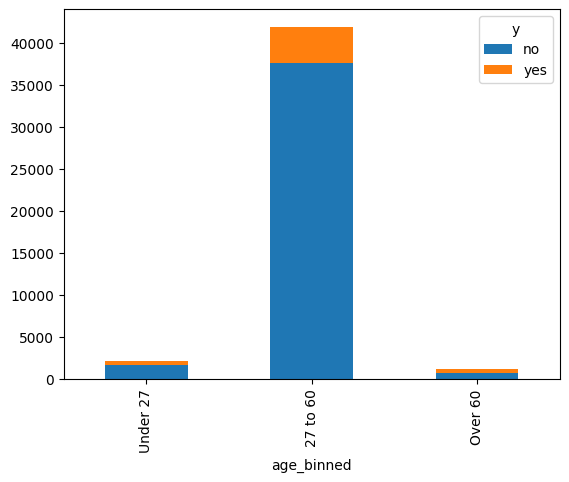

In [30]:
crosstab_age = pd.crosstab(bank_data['age_binned'],bank_data['y'])
crosstab_age.plot(kind='bar', stacked=True)

/var/folders/66/6vw881g500n1tz4mtjf1x44m0000gn/T/ipykernel_92089/93030911.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  crosstab_age_norm = crosstab_age.div(crosstab_age.sum(1), axis=0)


<Axes: xlabel='age_binned'>

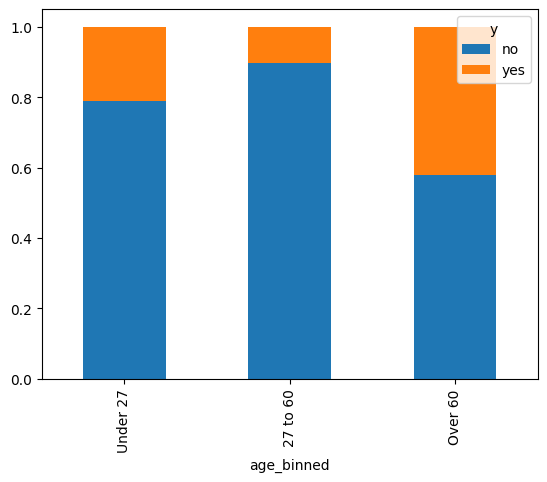

In [31]:
crosstab_age_norm = crosstab_age.div(crosstab_age.sum(1), axis=0)
crosstab_age_norm.plot(kind='bar', stacked=True)